# Image Acquisition

Acquire a full-frame image, a cropped rectangle scan, and images from multiple detectors.


### Run the servers

Make sure you are on the VPN and the AutoScript server is running. Then start the asyncroscopy Tango servers from the repository root:

```bash
uv run startup_scripts/run_servers.py
```


### Imports


In [1]:
import os
import json
import tango
import numpy as np
from pprint import pprint
import matplotlib.pyplot as plt
from tiled.client import from_uri

%matplotlib ipympl

### Ping servers


In [2]:
DB_HOST = "10.46.217.241"
# DB_HOST = "localhost"
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

server_names = ['stage', 'scan', 'eds', 'camera', 'data', 'microscope']

scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/microscope/default")
data = tango.DeviceProxy("asyncroscopy/data/default")

for proxy in [scan, microscope, data]:
    proxy.set_timeout_millis(120_000)
    proxy.ping()
    print(proxy.name(), proxy.state())

asyncroscopy/scan/default ON
asyncroscopy/microscope/default ON
asyncroscopy/data/default ON


### Set Tiled Client


In [3]:
config = json.loads(data.get_config())
config

{'host': '10.46.217.241',
 'port': 9091,
 'uri': 'http://10.46.217.241:9091',
 'save_path': 'outputs/tiled_acquisitions',
 'tiled_server': 'yes',
 'tiled_server_status': 'running; serving path; files register manually',
 'tiled_server_serving': 'outputs/tiled_acquisitions'}

In [4]:
client = from_uri(config.get("uri"))
print("Tiled keys:", list(client))

Tiled keys: []


### Configure scan


In [5]:
scan.dwell_time = 1e-6
scan.imsize = 512
scan.scan_region = [0, 0, 1, 1]
scan.output_format = ".h5"

print("dwell_time :", scan.dwell_time)
print("image size :", scan.imsize)
print("scan region:", list(scan.scan_region))


dwell_time : 1e-06
image size : 512
scan region: [np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(1.0)]


### Acquire a HAADF image


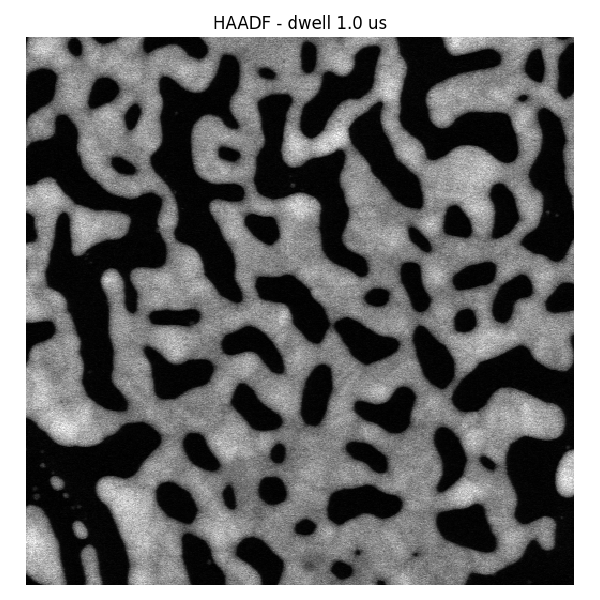

In [6]:
data_key = microscope.acquire_scanned_image(["haadf"])

image = client[data_key]["image"]["HAADF"].read()
metadata = dict(client[data_key]["image"]["HAADF"].metadata)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
ax.set_title(f"HAADF - dwell {scan.dwell_time * 1e6:.1f} us")
ax.axis("off")
plt.tight_layout()

In [7]:
print("Metadata:")
pprint(metadata)

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)


Metadata:
{'AccelerationVoltage': '200000',
 'AcquisitionDatetime': '2026-06-18T12:41:44.9605047Z',
 'AcquisitionStartDatetime': '2026-06-18T12:41:44Z',
 'Alpha': '-3.136e-06',
 'ApplicationSoftware': 'AutoScript TEM',
 'ApplicationSoftwareVersion': '1.15.0.484',
 'AzimuthAngle': '0.785398163',
 'AzimuthAngle_145': '2.35619449',
 'AzimuthAngle_157': '3.92699082',
 'AzimuthAngle_169': '5.49778714',
 'BeamConvergence': '0.0299979344',
 'BeamDiameter': '0',
 'Begin': '0',
 'Begin_118': '0',
 'Begin_126': '0.0728785469',
 'C1LensIntensity': '-0.451997418',
 'C2LensIntensity': '0.194438682',
 'C3LensIntensity': '0.352046547',
 'CameraLength': '0.091',
 'CollectionAngle': '0.7',
 'CollectionAngle_146': '0.7',
 'CollectionAngle_158': '0.7',
 'CollectionAngle_170': '0.7',
 'ComputerName': 'TITAN52340180',
 'ControlSoftwareVersion': '3.21.1',
 'DarkGainCorrectionType': 'DarkGain',
 'DarkGainCorrectionType_195': 'DarkGain',
 'DarkGainCorrectionType_206': 'DarkGain',
 'Defocus': '-2.8e-08',
 'Det

### Acquire multiple detectors


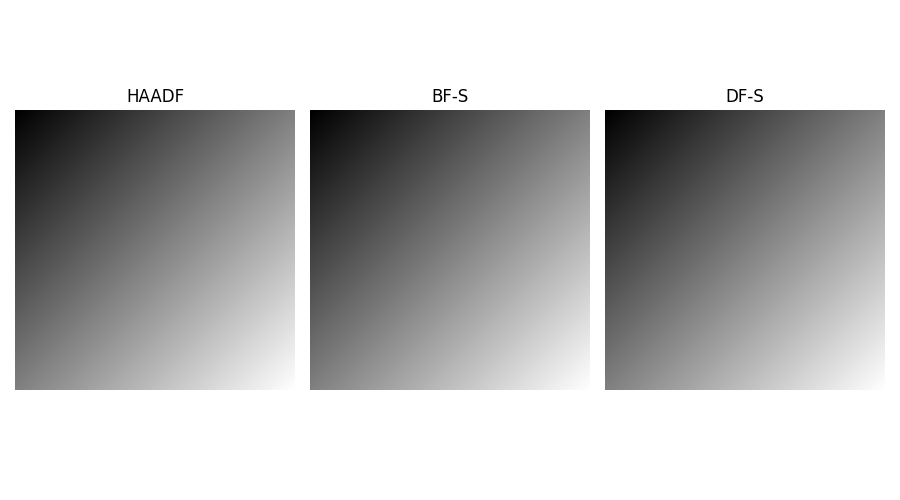

In [35]:
scan.dwell_time = 1e-6
scan.imsize = 512
scan.scan_region = [0, 0, 1, 1]
detector_list = ["HAADF", "BF-S", "DF-S"]
key = microscope.acquire_scanned_image(["HAADF", "BF-S", "DF-S"])
dset = client[key]["image"]

images = []
names = []
for detector_name in dset:
    image = dset[detector_name].read()
    images.append(image)
    names.append(detector_name)

fig, axes = plt.subplots(1, len(images), figsize=(3 * len(images), 5))
for ax, im, n in zip(axes, images, names):
    ax.imshow(im, cmap="gray")
    ax.set_title(str(n).upper())
    ax.axis("off")
fig.tight_layout()


## if using tiff as output fomrat(AutoScript Native) i.e scan.output_format = ".tiff"

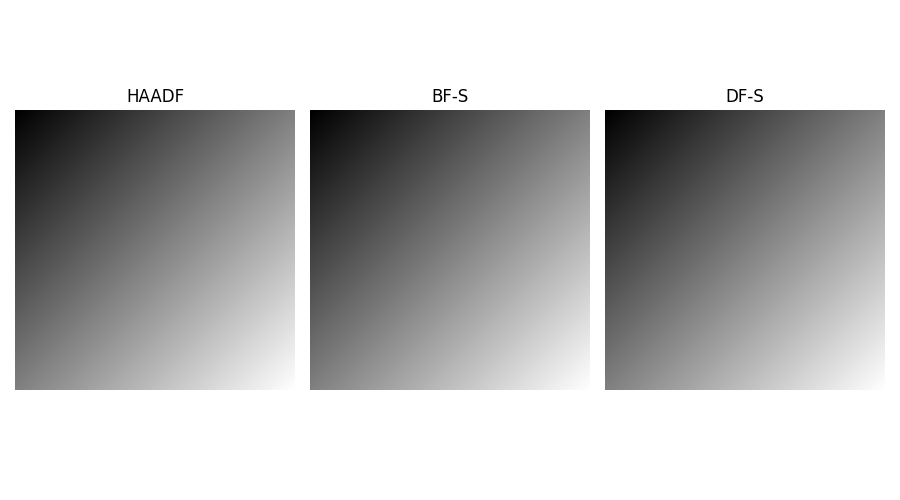

In [36]:
scan.dwell_time = 1e-6
scan.imsize = 512
scan.scan_region = [0, 0, 1, 1]
scan.output_format = ".tiff"

detector_list = ["HAADF", "BF-S", "DF-S"]
key = microscope.acquire_scanned_image(detector_list)   # returns the shared stem, e.g. "stem_image_20260604T123909936109"

images = []
names = []
for det in detector_list:
    node = client[f"{key}_{det.upper()}.tiff"]   # one TIFF per detector
    images.append(node.read())                   # read the image array directly
    names.append(det)

fig, axes = plt.subplots(1, len(images), figsize=(3 * len(images), 5))
for ax, im, n in zip(axes, images, names):
    ax.imshow(im, cmap="gray")
    ax.set_title(str(n).upper())
    ax.axis("off")
fig.tight_layout()

### Acquire a cropped rectangle scan


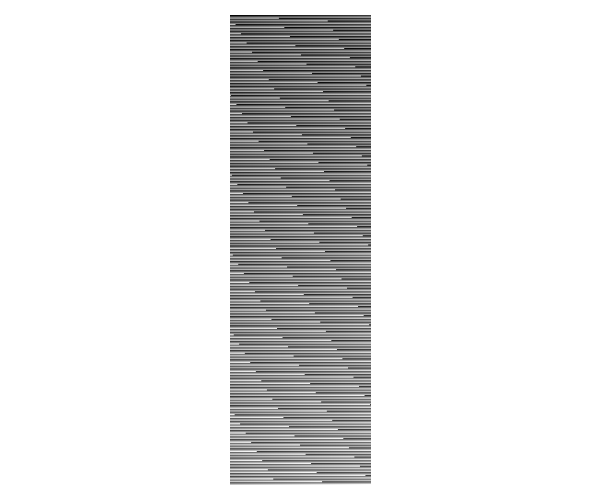

In [19]:
scan.dwell_time = 1e-6
scan.imsize = 512
scan.scan_region = [0, 0, .3, 1]

key = microscope.acquire_scanned_image(["HAADF"])
dset = client[key]["image"]
image = dset["HAADF"].read()

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(image, cmap="gray")
ax.axis("off")
plt.tight_layout()
